# Module Tutorial: MultiFit

The `multifit` module is used to make it easier to fit multi-gaussian, exponential etc. distributions.

The cell bellow imports the relevant modules, as well as sets up some trial data.

In [1]:
# imports/actions to set up tutorial environment
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, least_squares
# smfBursts imports
import smfbursts as smf
import smfbursts.datamodel.multifit as smfit
# load data
raw = smf.photonHDF5.load("data/dsdna_d7_d17_50_50_1.hdf5")
raw.photon_data[0].meas_specs['detectors_specs']['non_photon_id1'] = np.array([0,1], dtype=np.uint8) # old file, non-photon not automatically recorded
data = smf.photonHDF5.regularize_dets(raw)
# generate columns
bg = smf.fretfactory.make_bg(data, func=smf.bg.exp_mlefit, period=30.0, auto_threshold=True, F_bg=1.7)
bs = smf.fretfactory.make_burst_search(bg['bg'], m=10, F=6.0, streams=(smf.PhSel('0ex'), smf.PhSel('1ex1em')))
# useful gate
gFret = (smf.make_geq_gate(bs['NphDex_bg'], 30) & smf.make_geq_gate(bs['NphAA_bg'], 30) & 
         smf.make_geq_gate(bs['E_bg'], 0.0) & smf.make_lt_gate(bs['E_bg'], 1.0) & 
         smf.make_geq_gate(bs['S_bg'], 0.2) & smf.make_lt_gate(bs['S_bg'], 0.8))

## Basic optimization / fitting: Examples with normal/gaussian distributions

We will start this tutorial with examples demonstrating fits to multiple gaussian distributions.
This section will not go into deep detail about each distribution/functioning, for that skip to
the [detailed explanations](#Detailed-Explanations) section, which will describe each function in detail,
but will not attempt to show a "standard" workflow.

In general there are 2 broad methods used for fitting distributions.
1. $\chi^{2}$ of histograms (least-squares, can use least-squares or minimize type optimization algorithms)
2. Maximum likelihood estimation

### Multi-Gaussian $\chi^{2}$ fitting

The first step to fitting with the least squares method is always to prepare a histogram of the column.

The `multifit` module contains a special class, `Hist` that makes working with and fitting histograms easier.
It has the class method `Hist.from_columns()` that makes it easy to generate a histogram and access values
such as the PDF and CDF of the distribution, as well as bin-related parameters like binwidths, sizes and centers.
`Hist.from_columns()` has the signaure 
`Hist.from_columns(origin:DataS, columns:Sequence[Column], gate:GateGroup=None, **kwargs)->Hist:`
Where `**kwargs` is passed to [np.histogramdd](https://numpy.org/doc/stable/reference/generated/numpy.histogramdd.html)
`origin` should be source data object, `columns` can either be a single column or a list/tuple of columns, 
and if suppled `gate` is applied to all columns.

Because `**kwargs` is passed to [np.histogramdd](https://numpy.org/doc/stable/reference/generated/numpy.histogramdd.html)
the most common kwarg is `bins` wher

So first we will create a histogram of the background corrected proximity ratio:

In [2]:
bins = np.linspace(-0.1,1.1,25)
ehst = smfit.Hist.from_columns(data, bs['E_bg'], gate=gFret, bins=bins)

The cell bellow demonstrates how to use a `Hist` object.
The pdf attribute provides the proability density of the histogram 
(counts in a bin divided by binwidth divided by total counts in entire histogram).

It should be noted that the `bins` attribute always returns a tuple of numpy arrays.
This is because (as we will see later) multi-dimensional histograms are allowed, 
in which case each dimension has its own bins.

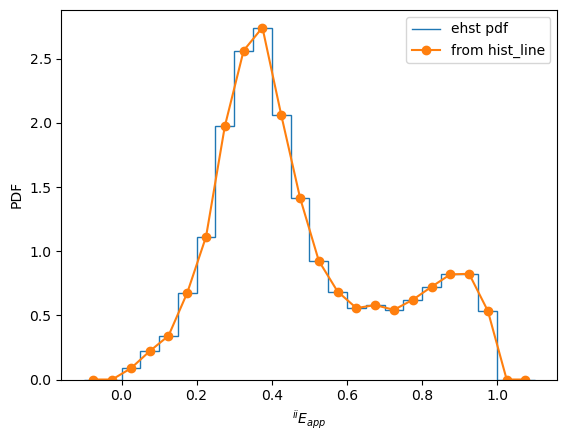

In [3]:
plt.stairs(ehst.pdf, ehst.bins[0], label='ehst pdf')
smf.plot.hist_line(data, bs['E_bg'], gate=gFret, bins=bins, normalize='PDF', marker='o', label='from hist_line')
plt.legend()

Now that the experimental distribution has been computed, we need to decide what type of distribution will be the best fit.

Lets say a bimodal normal distribution.
So we will try to minimize the least squares difference between a 2 guassian distibution and the experimental distribtion in `Hist`.

For this we will use the `fit_hist_cdf()` function.
The signature is `fit_hist_cdf(hist:Hist, func:FitFunc, init:np.ndarray, **kwargs)->OptimizeResult:`

- `hist` is the histogram of the experimental data to fit.
- `func` is a function defining the distribution to use for the fitting function.
  this function needs to fulfill a number of requirements,
  in the `multihist` module an function named `n<dist>_cdf` will work.
  For an number of normal distributions, the function to select is `ngaus_cdf`
- `init` is an array that provides some initial "guesses" for the distribution's parameters.
  
The oranization of `init` places each sub-distributions parameters consecuitively.
This can be confusing, so the easiest way to make the array is to use the `make_init()` function.

To make the `init` array, supply `make_init` with arrays of
1. the centers of each gaussian ($\mu$)
2. the standard deviatiosn of each gaussian ($\sigma$)
3. Optionally, the amplitudes of each gaussian (defaults to equal proportioning) through the `amps` keyword argument
4. Optionally, (but hightly recomended) the distribution function to be used through the `func` keywork argument (this adds checks)

In [4]:
mu = [0.3, 0.9]
sigma = [0.1, 0.1]
amps = [0.7, 0.3]
init = smfit.make_init(mu=mu, sigma=sigma, amps=amps, func=smfit.ngaus_cdf)
init

array([0.3, 0.1, 0.7, 0.9, 0.1])

You can also reverse the process with the `unwrap_param()` function.
Note that here the distribution function is a must, and goes first, followed by the `init` array.

In [5]:
paramsN = smfit.unwrap_param(smfit.ngaus_cdf, init)
paramsN

{'mu': array([0.3, 0.9]),
 'sigma': array([0.1, 0.1]),
 'amps': array([0.7, 0.3])}

Finally, while not strictly necessary, it is good to set upper and lower bounds for each parameter being fit.
This both prevents unreasonable parameter values, it can also prevent 
[scipy.optimize.minimize](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html)
from failing to optimize, as if the function encounters an invalid value (ie divide by 0 etc. error)
the minimization automatically terminates.

We can build such a bounds array with a function `make_bounds()` which has the same signature as `make_init()`
excpet that it omits the option to specify `amps`, and instead of specifying a 1D array per parameter,
you specify a Nx2 shaped array where N is the number of distributions.
Here the last dimension specifies the `[lower, uppper]` bounds of each paramter.

In [6]:
mubound = np.array([[0.0, 1.0], [0.0, 1.0]])
sigmabound = np.array([[1e-4, 0.5],[1e-4, 0.5]])
bounds = smfit.make_bounds(mu=mubound, sigma=sigmabound, func=smfit.ngaus_cdf)
bounds

array([[0.e+00, 1.e+00],
       [1.e-04, 5.e-01],
       [0.e+00, 1.e+00],
       [0.e+00, 1.e+00],
       [1.e-04, 5.e-01]])

Now that we have made the histogram, and specified the initial guess and bounds, we can optimize with `fit_hist_cdf()`, which wraps 
[scipy.optimize.minimize](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html).
It should be noted that all kwargs are passed to `minimize`, the most used of these will be `bounds` and `method`.

> **Note**
> In the next subsection, we will see how
> [scipy.optimize.minimize](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html).
> can be swapped out for
> [scipy.optimize.least_squares](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.least_squares.html).

The return value is the result of `scipy.optimize.minimize()`

Changing the `method` kwarg alters the iterative search algorithm.
For burst parameters, I have had the best results with 'Nelder-Mead'
but each case may be different.

In [7]:
res = smfit.fit_hist_cdf(ehst, smfit.ngaus_cdf, init, bounds=bounds, method="Nelder-Mead")
res

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.000837399691698277
             x: [ 3.570e-01  1.083e-01  7.150e-01  8.157e-01  1.436e-01]
           nit: 160
          nfev: 262
 final_simplex: (array([[ 3.570e-01,  1.083e-01, ...,  8.157e-01,
                         1.436e-01],
                       [ 3.570e-01,  1.083e-01, ...,  8.157e-01,
                         1.436e-01],
                       ...,
                       [ 3.570e-01,  1.083e-01, ...,  8.158e-01,
                         1.436e-01],
                       [ 3.570e-01,  1.082e-01, ...,  8.157e-01,
                         1.436e-01]], shape=(6, 5)), array([ 8.374e-04,  8.374e-04,  8.374e-04,  8.374e-04,
                        8.374e-04,  8.374e-04]))

The returned result is a 
[scipy.optimize.OptimizeResult](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.OptimizeResult.html)

The optimized paramers are found in the `res.x` attribute.
So we can use the `unwrap_param()`

In [8]:
smfit.unwrap_param(smfit.ngaus_cdf, res.x)

{'mu': array([0.35701843, 0.81573833]),
 'sigma': array([0.1082549, 0.143571 ]),
 'amps': array([0.71502278, 0.28497722])}

The plotting function `smf.plot.plot_multi_dist()` can be used to overlay a plot of the distribution over histograms/other plots.
Note that the distribution function supplied is a `n<dist>_pdf` function, 
and when plotting the raw histogram, `normalize` is set to `PDF`.
This is to be expected, and has to do with how the `fit_hist_cdf` function works.
The details will be explained later.

Text(0.5, 1.0, 'Min ($\\chi^{2}$) fit (normal) of FRET population')

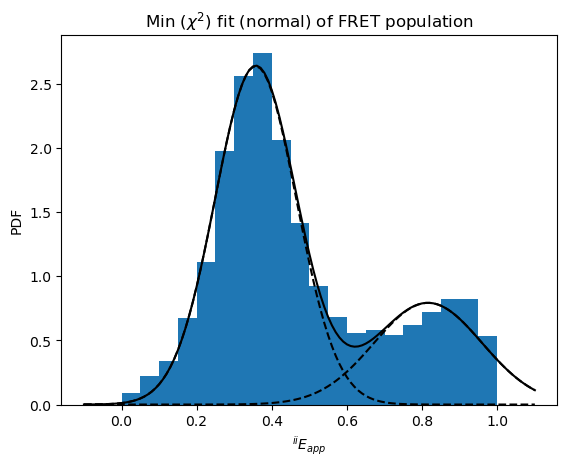

In [9]:
# plot origin data
smf.plot.hist_bar(data, bs['E_bg'], gate=gFret, bins=bins, normalize='PDF')
# plot distribution
smf.plot.plot_multi_dist(smfit.ngaus_pdf, res.x, np.linspace(-0.1, 1.1, 121), dist_kwargs={'c':'k', 'zorder':1.0}, subdist_kwargs={'ls':'--', 'c':'k'})
plt.title(r"Min ($\chi^{2}$) fit (normal) of FRET population") # just gives the plot a title

Below is a cell for plotting the residuals.

<class 'matplotlib.patches.StepPatch'>


Text(0.5, 0, '$^{ii}E$')

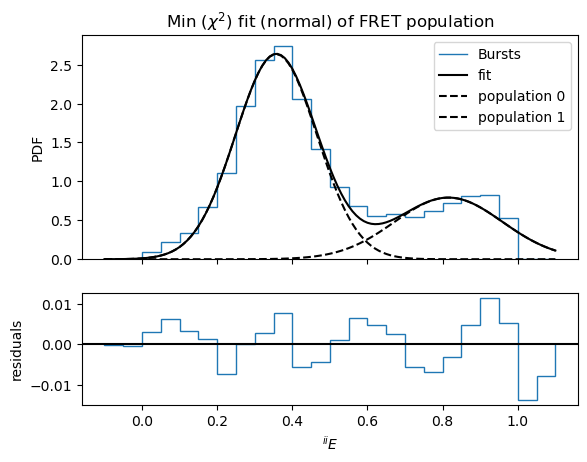

In [10]:
# plot with residuals
fig, ax = plt.subplots(2,1, height_ratios=[2,1], sharex=True)
ax[0].stairs(ehst.pdf, ehst.bins[0], label='Bursts')
smf.plot.plot_multi_dist(smfit.ngaus_pdf, res.x, np.linspace(-0.1,1.1,121), dist_kwargs={'c':'k', 'label':'fit'}, subdist_kwargs=[{'ls':'--','c':'k','label':f'population {i}'} for i in range(2)], ax=ax[0])
ax[0].set_title(r"Min ($\chi^{2}$) fit (normal) of FRET population") # just gives the plot a title
ax[0].set_ylabel('PDF')
ax[0].legend()
resid = ehst.pmf - smfit.ngaus_cdfbins(res.x, ehst.bins[0])
print(type(ax[1].stairs(resid, ehst.bins[0])))
ax[1].axhline(0, c='k')
ax[1].set_ylabel("residuals")
ax[1].set_xlabel("$^{ii}E$")

### Least Squares Optimization

Scipy also provides the 
[scipy.optimize.least_squares](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.least_squares.html)
algorithm, which provides a different set of algorithms for optimization.
The `min_func` keyword argument of `fit_hist_cdf()` sets the minimizing function.

The multifit module has 2 specially designed functions for the `min_func` keyword argument:
`min_cdffit` and `lsq_cdffit`.

`min_cdffit` uses [scipy.optimize.minimize](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html)
while
`lsq_cdffit` uses [scipy.optimize.least_squares](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.least_squares.html).

> **Note**
>
> [scipy.optimize.least_squares](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.least_squares.html).
> takes bounds in the transposed manner, so you will need to spcify bounds as `bounds.T` from the `make_bounds()` function.
>
> Also, note that if using Levenberg-Marquardt algorithm, bounds cannot be specified.

So to fit with the least-squares scipy function, we simply specify:

<class 'matplotlib.patches.StepPatch'>


{'mu': array([0.35701563, 0.81572843]),
 'sigma': array([0.10824748, 0.1435734 ]),
 'amps': array([0.71497881, 0.28502119])}

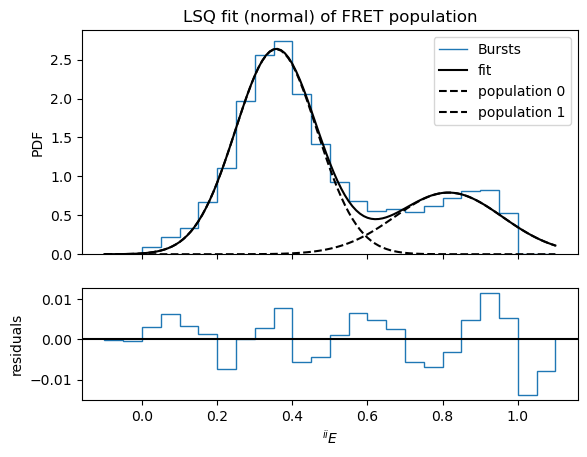

In [11]:
res = smfit.fit_hist_cdf(ehst, smfit.ngaus_cdf, init, bounds=bounds.T, min_func=smfit.lsq_cdffit)

# plot with residuals
fig, ax = plt.subplots(2,1, height_ratios=[2,1], sharex=True)
ax[0].stairs(ehst.pdf, ehst.bins[0], label='Bursts')
smf.plot.plot_multi_dist(smfit.ngaus_pdf, res.x, np.linspace(-0.1,1.1,121), dist_kwargs={'c':'k', 'label':'fit'}, subdist_kwargs=[{'ls':'--','c':'k','label':f'population {i}'} for i in range(2)], ax=ax[0])
ax[0].set_title(r"LSQ fit (normal) of FRET population") # just gives the plot a title
ax[0].set_ylabel('PDF')
ax[0].legend()
resid = ehst.pmf - smfit.ngaus_cdfbins(res.x, ehst.bins[0])
print(type(ax[1].stairs(resid, ehst.bins[0])))
ax[1].axhline(0, c='k')
ax[1].set_ylabel("residuals")
ax[1].set_xlabel("$^{ii}E$")

# output unwrapped result
smfit.unwrap_param(smfit.ngaus_cdf, res.x)

### MLE model optimization

It is also possible to fit using maximum likelihood estimation.

The basic definition of the maximum likelihood esitmation is:

$MLE(\mathbf{y} | \theta) = \prod_{k=1}^n{P(y_{k}|\theta)}$

And therefore 

$\hat{\theta} = \underset{\theta \in \Theta}{argmax}(MLE(\mathbf{y}|\theta))$

To perform an optimization with MLE, use the `fit_mle

Instead of using a `n<dist>_cdf` function, for MLE, the `n<dist>_pdf` functions should be used.

{'mu': array([0.36594361, 0.82667902]),
 'sigma': array([0.12408661, 0.10270692]),
 'amps': array([0.76627015, 0.23372985])}

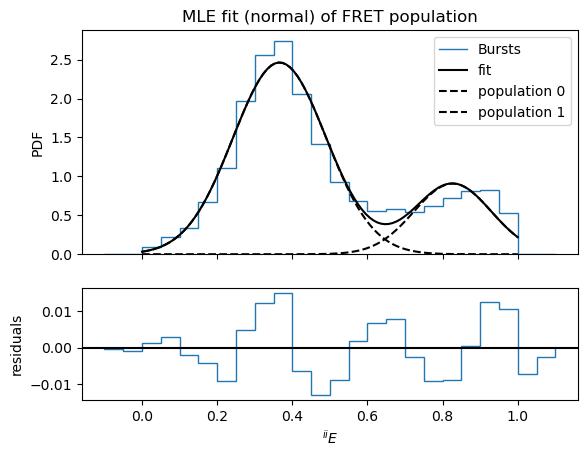

In [12]:
res = smfit.fit_column_mle(data, bs['E_bg'], smfit.ngaus_pdf, init, gate=gFret, bounds=bounds, method='Nelder-Mead')

# plot with residuals
fig, ax = plt.subplots(2,1, height_ratios=[2,1], sharex=True)
ax[0].stairs(ehst.pdf, ehst.bins[0], label='Bursts')
smf.plot.plot_multi_dist(smfit.ngaus_pdf, res.x, np.linspace(0,1,100), 
                         dist_kwargs={'c':'k', 'label':'fit'}, 
                         subdist_kwargs=[{'ls':'--','c':'k','label':f'population {i}'} 
                                         for i in range(2)], ax=ax[0], label='Bursts')
ax[0].set_title("MLE fit (normal) of FRET population") # just gives the plot a title
ax[0].set_ylabel('PDF')
ax[0].legend()
resid = ehst.pmf - smfit.ngaus_cdfbins(res.x, ehst.bins[0])
ax[1].stairs(resid, ehst.bins[0])
ax[1].axhline(0, c='k')
ax[1].set_ylabel("residuals")
ax[1].set_xlabel("$^{ii}E$")

smfit.unwrap_param(smfit.ngaus_pdf, res.x)

### Multi-dimensional fit

Finally, it is possible to fit multiple columns to a multi-variate distribution.

These use `nd<dist>_cdf()` and `nd<dist>_pdf()` distribution functions, and the `smfit.fit_hist_ndcdf()` and `fit_columns_ndmle()` functions.

Like before, we use the CDF for fitting histograms, and PDF for MLE based fittings.

Defining the individual parameters becomes more complicated, as the size of parameters depends on the number of dimensions.
For the multivariate normal distribution (an nd gaussian) the center ($\mu$) and the variance ($\sigma$) becomes a matrix ($\Sigma$)
However, $\Sigma$ is restricted to being symetric (and positive semidefinite) the number of free parameters is just the upper diagonal matrix.
(`multifit` chooses the upper diagonal, but this is just the chosen formalism, the lower diagonal is equivalent).
All of these get "unwrapped" into a 1-d matrix, with the same `dist0_0, dist0_1,... amp0, ...distN_M` organization, with the vectors, and portions of matrices unwrapped.

Because of this greater ambiguity, building the init and bounds matrices cannot be done used `make_init()` and `make_bounds()`,
Instead the functions `make_nd_init()` and `make_nd_bounds()` are used to build bounds of `nd<dist_...()` functions.
For `make_nd_init()` each sequence of parameters is a multi-dimensional array.
The organization of indexes is `[dist, ...]` where ... is the dimensions of the parameter.

For `make_nd_bounds()` it is `[dist, lower/upper, ...]` ie specify the distribution first, 
then dimension 2 is always size 2, specifying the `[lower, upper]` bounds,
and each distributions lower/upper bounds are in the remaining dimensions, taking the shape of the given parameter.

For $\Sigma$ we still specify as a full matrix (2d array), but when the `init` array is constructed, the elements below the diagnoal are ignored.

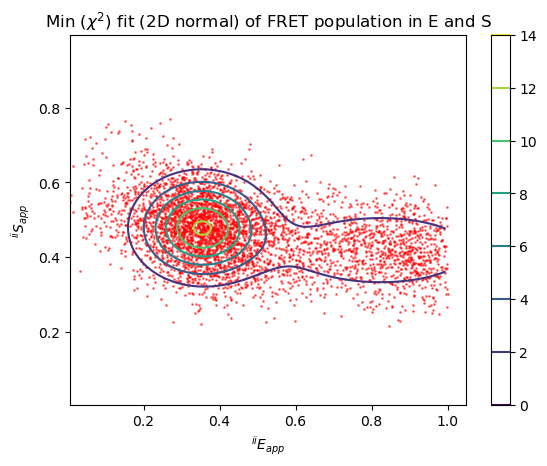

In [13]:
# make multi-dimentional mu and sigma arrays
mu = np.array([[0.2, 0.5], 
               [0.8, 0.5]])
sigma = np.array([[[0.01, 0.0],[0.0, 0.01]],
                  [[0.01, 0.0],[0.0, 0.01]]])
# build into init array
init = smfit.make_nd_init(smfit.ndgaus_cdf, mu, sigma)

# make multi-dimentional mu and sigma arrays
mu_b = np.array([[[0.0, 0.0], [1.0, 1.0]],
                 [[0.0, 0.0], [1.0, 1.0]]])
sigma_b = np.array([[[[1e-8, -1e-8],[-1e-8, 1e-8]], # lower bounds dist 1
                     [[0.04, 1e-4],[1e-4, 0.04]]], # upper bounds dist 1
                    [[[1e-8, -1e-8],[-1e-8, 1e-8]], # lower bounds dist 2
                     [[0.04, 1e-4],[1e-4, 0.04]]]]) # upper bounds dist 2
bounds = smfit.make_nd_bounds(smfit.ndgaus_cdf, mu_b, sigma_b)

# make histogram and fit
eshst = smfit.Hist.from_columns(data, (bs['E_bg'], bs['S_bg']), gate=gFret, bins=(np.linspace(0,1,21), np.linspace(0,1,11)))
res = smfit.fit_hist_cdf(eshst, smfit.ndgaus_cdf, init, min_func=smfit.min_cdffit, method='Nelder-Mead', bounds=bounds)

# plot
locs = np.linspace(0,1, 100)
mid_locs = locs[:-1] + np.diff(locs)/2
blocs = np.stack(np.meshgrid(mid_locs, mid_locs), axis=-1)
plt.contour(mid_locs, mid_locs, smfit.ndgaus_pdf(res.x, blocs))
smf.plot.scatter(data, bs['E_bg'], bs['S_bg'], gate=gFret, s=1.0, c='r', alpha=0.5)
plt.title(r"Min ($\chi^{2}$) fit (2D normal) of FRET population in E and S") # adds title
plt.colorbar() # adds colorbar of contour plot

Just as building initial parameters requires an `nd` version, "unwrapping" requires the `unwrap_nd_param` function.

In [14]:
smfit.unwrap_nd_param(smfit.ndgaus_cdf, 2, res.x)

{'mu': [array([0.35262954, 0.47908135]), array([0.82403009, 0.41852776])],
 'sigma': [array([[1.03687727e-02, 3.78704787e-07],
         [3.78704787e-07, 6.72341556e-03]]),
  array([[3.99994611e-02, 2.36207012e-07],
         [2.36207012e-07, 5.57499796e-03]])],
 'amps': array([0.63682468, 0.36317532])}

We can also perform an MLE optimization on multiple columns.

{'mu': [array([0.36022998, 0.47868342]), array([0.81156685, 0.41779157])],
 'sigma': [array([[1.42359488e-02, 3.36584266e-07],
         [3.36584266e-07, 6.87709091e-03]]),
  array([[ 1.31263845e-02, -2.86088987e-10],
         [-2.86088987e-10,  5.09642414e-03]])],
 'amps': array([0.74873393, 0.25126607])}

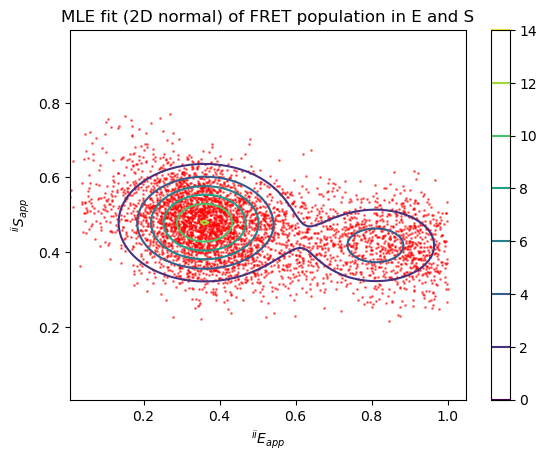

In [15]:
res = smfit.fit_column_mle(data, (bs['E_bg'], bs['S_bg']), smfit.ndgaus_pdf, init, gate=gFret, bounds=bounds, method='Nelder-Mead')

locs = np.linspace(0,1, 100)
mid_locs = locs[:-1] + np.diff(locs)/2
blocs = np.stack(np.meshgrid(mid_locs, mid_locs), axis=-1)
plt.contour(mid_locs, mid_locs, smfit.ndgaus_pdf(res.x, blocs))
smf.plot.scatter(data, bs['E_bg'], bs['S_bg'], gate=gFret, s=1.0, c='r', alpha=0.5)
plt.title("MLE fit (2D normal) of FRET population in E and S") # adds title
plt.colorbar()

smfit.unwrap_nd_param(smfit.ndgaus_cdf, 2, res.x)

## Fitting other distributions

Other distributions following the same naming convention are given.
These are just as easily fit, the same paring of `n<dist>_pdf` with `fit_column_mle()` and `n<dist>_cdf` with `fit_hist_lsq()` still applies.

Lets see an example with the beta distribution, which works better when fitting *raw* ratios, as these are typically constrained from \[0, 1\], just as is the beta distribution:

> **note** that the parameter names for beta are now `a` and `b`

{'a': array([ 9.42652932, 10.16986336]),
 'b': array([16.36025016,  3.60506519]),
 'amps': array([0.72269119, 0.27730881])}

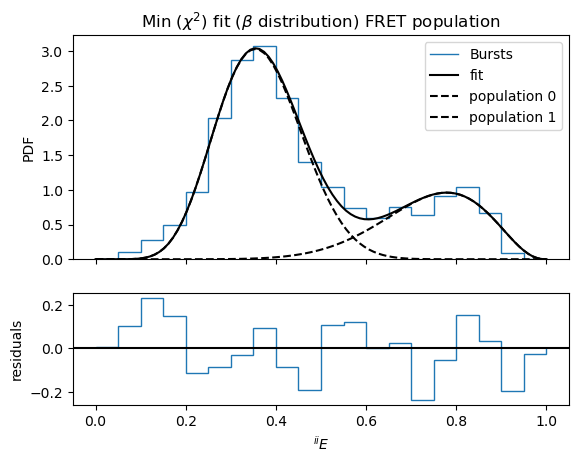

In [16]:
init = smfit.make_init(a=[2, 12], b=[14, 2], amps=[0.7, 0.3], func=smfit.nbeta_cdf)
bounds = smfit.make_bounds(a=[[1,50], [1,50]], b=[[1,50], [1,50]], func=smfit.nbeta_cdf)
bins = np.linspace(0, 1, 21) # because using beta, and therefore E_raw, range now 0 to 1, no tails for bg
# make histogram
ehst_raw = smfit.Hist.from_columns(data, bs['E_raw'], bins=bins, gate=gFret)
# Perform fit
res = smfit.fit_hist_cdf(ehst_raw, smfit.nbeta_cdf, init, bounds=bounds, method='Nelder-Mead')

# plot with residuals
fig, ax = plt.subplots(2,1, height_ratios=[2,1], sharex=True)
ax[0].stairs(ehst_raw.pdf, ehst_raw.bins[0], label='Bursts')
smf.plot.plot_multi_dist(smfit.nbeta_pdf, res.x, np.linspace(0,1,100), dist_kwargs={'c':'k', 'label':'fit'}, subdist_kwargs=[{'ls':'--','c':'k','label':f'population {i}'} for i in range(2)], ax=ax[0], label='Bursts')
ax[0].set_title(r"Min ($\chi^{2}$) fit ($\beta$ distribution) FRET population")
ax[0].set_ylabel('PDF')
ax[0].legend()
resid = ehst_raw.pdf - smfit.nbeta_pdf(res.x, ehst_raw.bincenters[0])
ax[1].stairs(resid, ehst_raw.bins[0])
ax[1].axhline(0, c='k')
ax[1].set_ylabel("residuals")
ax[1].set_xlabel("$^{ii}E$")

smfit.unwrap_param(smfit.nbeta_cdf, res.x)

and we can similarly do the same with mle:

{'a': array([ 6.39329927, 19.02602843]),
 'b': array([10.83049777,  5.87382537]),
 'amps': array([0.78050841, 0.21949159])}

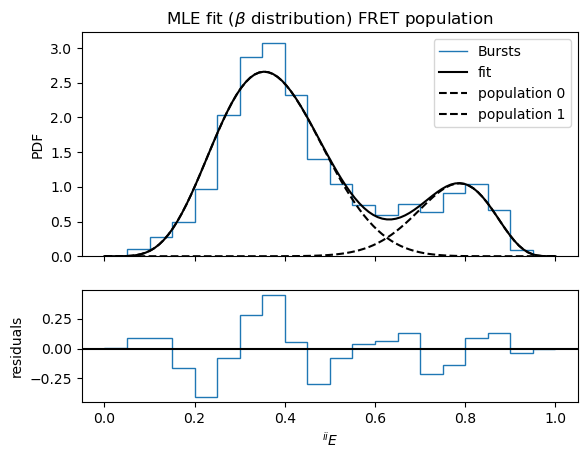

In [17]:
res = smfit.fit_column_mle(data, bs['E_raw'], smfit.nbeta_pdf, init, bounds=bounds, method='Nelder-Mead', gate=gFret)

# plot with residuals
fig, ax = plt.subplots(2,1, height_ratios=[2,1], sharex=True)
ax[0].stairs(ehst_raw.pdf, ehst_raw.bins[0], label='Bursts')
smf.plot.plot_multi_dist(smfit.nbeta_pdf, res.x, np.linspace(0,1,100), dist_kwargs={'c':'k', 'label':'fit'}, subdist_kwargs=[{'ls':'--','c':'k','label':f'population {i}'} for i in range(2)], ax=ax[0], label='Bursts')
ax[0].set_title(r"MLE fit ($\beta$ distribution) FRET population")
ax[0].set_ylabel('PDF')
ax[0].legend()
resid = ehst_raw.pdf - smfit.nbeta_pdf(res.x, ehst_raw.bincenters[0])
ax[1].stairs(resid, ehst_raw.bins[0])
ax[1].axhline(0, c='k')
ax[1].set_ylabel("residuals")
ax[1].set_xlabel("$^{ii}E$")

smfit.unwrap_param(smfit.nbeta_cdf, res.x)

## Detailed Explanations

### Core concepts and definitions of N-Distributions

All optimizations to a distribution (multi or otherwise), require a function to generate the hypothetical distribution to compare to the real data.
These always have a set of required parameters.
Both
[scipy.optimize.minimize](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html) 
and 
[scipy.optimize.least_squares](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.least_squares.html)
recieve their parameters as a single,  1D numpy array.
These two optimization functions from scipy acheive the same basic task, but have different iteration algorithms, 
and their objective functions must return either a single float or an array respectively.

The `n<dist>_...` and `nd<dist>_...` functions make an N-distribution.
An N-distriubtion can be defined as follows:

$$F(x, \Theta) = \sum){i=1}^{N}{[a_{i}f(x, \theta_{i})]}$$

Where $F$ is the N-distribution, $f$ is the "sub" distribution, ie a clasical single-statistical distriubtion,
$\Theta$ is composed of all $\theta$s, which are the parameter values of the sub-distribution.
$a_{i}$ is the "amplitude" of the $i$th distribution, and
$x$ is the independent variable.

As probability distribution functions require the integral over the support to be 1, and nearly all other
funtions of a distribution have some equivalent requirement, $\sum_{i=1}^{N}{a_{i}} = 1$.
This means that $a_{N} = 1 - \sum_{i=1}^{N-1}{a_{i}}$.

Therefore if $M$ is the number of paramter values ith $\theta$, there are $N * (M+1) - 1$ free parameters in a given N-distribution.

#### Rescaling amplitudes

The `n(d)<dist>_...` functions (with the exception of `n<dist>_free` use "rescaled" amplitudes.
The motivation behind this is because 
[scipy.optimize.minimize](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html) 
only allows setting bounds on the values of a given parameter within a fixed range.
Thus, the optimization can attemp invalid combinations of $a_{i}$, where $\sum_{i=1}^{N-1} > 1$.

Therefore the "rescaled" amplituded $a_{i}^{\prime}$ has a range of $(0,1)$.

Rescaled amplitudes can be thought of as "residual amplitudes", 
i.e. $a_{i}^{\prime}$ is the amplitude of what is "left over" after the $j<i$ amplitudes have been accounted for.

Strictly this is defned as follows:

$a_{i} = S_{i}a_{i}^{\prime}$

where 

$S_{i} = \sum_{j=1}^{i-1}{a_{i}}$

`rescale_amps()` converts $\vec{a}$ to $\vec{a^{\prime}}$, ie `amps_prime = rescale_amps(amps)`
while `retrieve_amps()` converts $\vec{a^{\prime}}$ to $\vec{a}$.

In [18]:
smfit.rescale_amps(np.array([0.3, 0.5, 0.2])) # convert true amp to rescale amp

array([0.3       , 0.71428571])

In [19]:
smfit.retrieve_amps(np.array([0.5, 0.5])) # convert rescaled amp to true amp

array([0.5 , 0.25, 0.25])

### Python implementation details

The `n(d)<dist>_...()` functions all have the signature `n(d)<dist>_...(params:np.ndarray, x:np.ndarray)`.
The `params` array is always a 1-D numpy *float* array (`scipy.optimize.minimize` does not support integral arrays).

`params` is organized with all parameters of the nth distribution next to each other, and the rescaled amplitude at the end.
i.e. `p0_0, p0_1, ..., p0_M, amp0, p1_0, ..., p1_M, amp1, ..., pN_0, ...pN_M`

### List of `<dist>` types

1. `gaus` parameters: `mu`, `sigma` uses [scipy.stats.norm](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html)
2. `beta` parameters `a`, `b` uses [scipy.stats.beta](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.beta.html)
3. `nexponnorm`: parmaeters `K` uses [scipy.stats.exponnorm](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.exponnorm.html)


### Distribution functions

The `...` portion of `n(d)<dist>_...` indicates the behavior of the output.

The different types are:

1. `pdf` the probability distribution function, $\int_{A}{F_{PDF}(x, \Theta) dx} \cong 1$ where $A$ is the support for the distribution
2. `cdf` the cumulative distribution function, $F_{CDF}(X, \Theta) = \int_{0}^{X}{F(x, \Theta)dx}$ therefor $F_{CDF}(max(x), \Theta) = 1$
3. `cdfbins` treats `x` as bins of a histogram, therefore output is $N-1$ where $N$ is the size of `x`, each return value is difference in CDF between consecutive values.
   This makes the return values similar to a probability mass function.
4. `free` no longer uses rescaled amplitudes, so params is always 1 larger than the other functions, $\int_{A}{F_{free}(x,\Theta)dx} = \sum_{i=1}^{N}{a_{i}}$

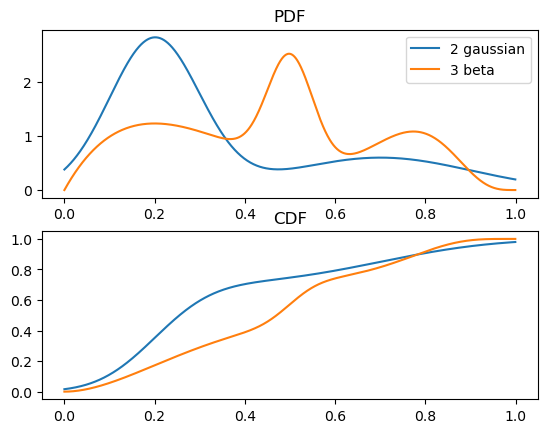

In [20]:
fig, ax = plt.subplots(2,1)

x = np.r_[0:1:0.001] # create x array for 0 to 1
pgaus = np.array([ # Param array
    0.2, # mu0
    0.1, # sigam0
    0.7, # amp0
    0.7, # mu 1
    0.2, # sigma1
])

pdfgaus = smfit.ngaus_pdf(pgaus, x)
ax[0].plot(x,pdfgaus, label=r'2 gaussian')
cdfgaus = smfit.ngaus_cdf(pgaus, x)
ax[1].plot(x, cdfgaus, label=r'2 gaussian')

pbeta = np.array([ # Param array for beta, has a, b paramters per distribution
    2.0,  # a0
    5.0, # b0
    0.5,  # amp0
    50.0, # a1
    50.0, # b1
    0.5, # amp1
    15.0, # a2
    5.0,  # b2
])

pdfbeta = smfit.nbeta_pdf(pbeta, x)
ax[0].plot(x, pdfbeta, label=r'3 beta')
cdfbeta = smfit.nbeta_cdf(pbeta, x)
ax[1].plot(x, cdfbeta, label=r'3 beta')

ax[0].set_title("PDF")
ax[1].set_title("CDF")
ax[0].legend()

### `value_mle()`, `value_lsq()`, `value_lsq_by_cdf()` functions

[scipy.optimize.minimize](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html) also requires the input function to return a float value.
Therefore it is necessary to have a function that converts the real data, and the distribution function into a value that is minimized for the optimal parameter values.

The `value_...()` functions have a basic signature of `value_...(params:np.ndarray, [input0, ...] , func, **kwargs)`.
Where `func` is a distribution function.
Each `value_...()` is designed for a different sort of `n(d)<dist>_...()` distribution function.


#### `value_mle()` calculation

`value_mle()` has the signature of `value_mle(params:np.ndarray, samples:np.ndarray, func:FitFunc, **kwargs)->float`
It computes the negative-log-sum of `func` at the values of `samples`
i.e. 

$-\log(MLE) = -\sum_{i=1}^{N}{\log(F(x_{i}, \Theta))} = -\log(\prod_{i=1}^{N}{F(x_{i},\Theta})$

where `param` is equivalent to $\Theta$, and `samples` is an array$x$.

This means that the input function should give a probability of $x|\Theta$ so a PDF of PMF like distribution should be used.

To perform an optimization with `scipy.optimize.minimize` we would do the following

In [21]:
init = np.array([
    0.1, # mu0
    0.1, # sigma0
    0.6, # amp0
    0.6, # mu1
    0.1 # sigma0
])

bounds = np.array([
    [0.0, 1.0], # mu0 bounds
    [0.0, 1.0], # sigma0 bounds
    [1e-8, 1-1e-8], # amp0 bounds
    [0.0, 1.0], # mu1 bounds
    [0.0, 1.0] # sigma1 bounds
])
res = minimize(smfit.value_mle, init, args=(data.get_column(bs['E_bg'], gFret), smfit.ngaus_pdf), bounds=bounds, method='Nelder-Mead')
res

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -246.02434757181317
             x: [ 1.573e-01  1.417e-01  1.000e-08  4.736e-01  2.287e-01]
           nit: 77
          nfev: 140
 final_simplex: (array([[ 1.573e-01,  1.417e-01, ...,  4.736e-01,
                         2.287e-01],
                       [ 1.573e-01,  1.417e-01, ...,  4.737e-01,
                         2.287e-01],
                       ...,
                       [ 1.573e-01,  1.417e-01, ...,  4.737e-01,
                         2.287e-01],
                       [ 1.573e-01,  1.417e-01, ...,  4.736e-01,
                         2.286e-01]], shape=(6, 5)), array([-2.460e+02, -2.460e+02, -2.460e+02, -2.460e+02,
                       -2.460e+02, -2.460e+02]))

It should be noted that the function `fit_column_mle()` is basically just a wrapper that makes the above call simpler.

#### `value_lsq()` calculation

The basic signature is `value_lsq(params:np.ndarray, x:np.ndarray, y:np.ndarray, func:FitFunc, **kwargs)`

It returns $\sum_{i=1}^{N}(y_{i}-{F(x_{i},\Theta))^{2}}$ where  `x` is the array of values of $x_{i}$, and `y` is the array of values of $y_{i}$
So `x` and `y` should be the same size, and `y` should be normalized in the same way as the distribution function.

An optimization looks like this:

In [22]:
ehst, bins = np.histogram(data.get_column(bs['E_bg'], gFret), bins=np.linspace(0,1,21)) # histogram E values

blocs = bins[:-1] + np.diff(bins) / 2 # compute middle of bins
ehst = ehst / ehst.sum() / np.diff(bins) # normalize values to PDF-like, not division by binwidths is necessary to make PDF, not PMF

res = minimize(smfit.value_lsq, init, args=(blocs, ehst, smfit.ngaus_pdf), bounds=bounds, method='Nelder-Mead')
res

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 2.543893458980417
             x: [ 0.000e+00  1.000e+00  3.692e-01  3.616e-01  1.034e-01]
           nit: 167
          nfev: 280
 final_simplex: (array([[ 0.000e+00,  1.000e+00, ...,  3.616e-01,
                         1.034e-01],
                       [ 0.000e+00,  1.000e+00, ...,  3.616e-01,
                         1.034e-01],
                       ...,
                       [ 0.000e+00,  1.000e+00, ...,  3.616e-01,
                         1.034e-01],
                       [ 0.000e+00,  1.000e+00, ...,  3.616e-01,
                         1.034e-01]], shape=(6, 5)), array([ 2.544e+00,  2.544e+00,  2.544e+00,  2.544e+00,
                        2.544e+00,  2.544e+00]))

### `value_lsq_by_cdf()` calculation

The `value_lsq()` has a limitation, in so far as the value of the distribution is computed at the location of the center of the histogram bin.

A more accurate computation of the value is the difference in the CDF between the start and end of the bin.

Furthermore, if we assume the histogram is normalized so that the sum of all bins is 1, but the distribution has a larger support than bins,
we must renormalize the CDF for the range of bins.

This is the purpose of `value_lsq_by_cdf()`

Mathematically it computes the following ($N$ is the number of bins, therefore `x` is size $N+1$, and `y` is size $N$):

$LSQ(\Theta) = \sum_{i=1}^{N}{(y_{i}-\Delta_{i}^{norm}F(x, \Theta'))^{2}}$ 

where 

$$\Delta_{i}^{norm}F(x, \Theta) = \frac{(F(x_{i+1}, \Theta) - F(x_{i}, \Theta))}{(F(x_{N+1}, \Theta) - F(x_{0}, \Theta))}$$

Note that the second factor normalizes the CDF

Its signature is `value_lsq_by_cdf(params:np.ndarray, bins:np.ndarray, y:np.ndarray, func:FitFunc, **kwargs)`

Optimizing with `value_lsq_by_cdf()` would like bellow:

In [23]:
ehst, bins = np.histogram(data.get_column(bs['E_bg'], gFret), bins=np.linspace(0,1,21)) # histogram E values

ehst = ehst / ehst.sum() # normalize values to sum to 1

res = minimize(smfit.value_lsq_by_cdf, init, args=(bins, ehst, smfit.ngaus_cdf), bounds=bounds, method='Nelder-Mead')
res

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.011240114052284677
             x: [ 1.000e-01  7.820e-02  1.000e-08  3.743e-01  1.624e-01]
           nit: 219
          nfev: 349
 final_simplex: (array([[ 1.000e-01,  7.820e-02, ...,  3.743e-01,
                         1.624e-01],
                       [ 9.998e-02,  7.815e-02, ...,  3.743e-01,
                         1.624e-01],
                       ...,
                       [ 1.001e-01,  7.815e-02, ...,  3.743e-01,
                         1.624e-01],
                       [ 1.001e-01,  7.827e-02, ...,  3.743e-01,
                         1.624e-01]], shape=(6, 5)), array([ 1.124e-02,  1.124e-02,  1.124e-02,  1.124e-02,
                        1.124e-02,  1.124e-02]))

Like the `fit_column_mle()` function, the `fit_hist_cdf()` function is also essentially just a wrapper around `value_lsq_by_cdf()`, this time using a histogram.

Importantly the process of normalizing the histogram is what the `Hist.pmf` atribute of the `Hist` class does.

### `value_diff()` and `value_diff_by_cdf()` functions

When using the 
[scipy.optimize.least_squares](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.least_squares.html)
algorithm, which are in turn used by the `lsq_anyfit()` and `lsq_cdffit()` wrappers,
simply return the difference between the observed distribution values, and those of the fit function at each point, returning an array.

#### `value_diff()` function

`value_diff()` has the signature `value_diff(params, x, y, func)` where `params` is the parameter array ($\Phi$) 
for the `n<dist>_...`/`nd<dist>_...` function `func`, and `x` is the input values (array of $x$), and `y` the observed values (array of $y$).
And the return value is defined as $y_{i} - F(x,\Phi)$ (returned as an array). 
Note that is the "inner" part of the statemet for `value_lsq()` before squaring each element and summing.
`value_diff()` importanlty can take nD inputs, and still work with 
[scipy.optimize.least_squares](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.least_squares.html)
because it flattens the output to a 1D array.

So we can see the "unwrapped" code of `smf.fit_hist_pdf()` below

In [24]:
ehst, bins = np.histogram(data.get_column(bs['E_bg'], gFret), bins=np.linspace(0,1,21)) # histogram E values

ehst = ehst / ehst.sum() / np.diff(bins)# normalize values to sum to 1 and multiply by width to get estimated PDF

bincenters = bins[:-1] + np.diff(bins) / 2 # evaluate bin centers

res = least_squares(smfit.value_diff, init, args=(bincenters, ehst, smfit.ngaus_pdf), bounds=bounds.T)
res

     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [ 6.839e-02  1.456e-01 ...  1.941e-01  2.236e-02]
           x: [ 3.557e-01  1.054e-01  6.875e-01  8.304e-01  1.696e-01]
        cost: 0.09631365475645666
         jac: [[ 5.653e-01 -1.593e+00 ...  2.616e-04 -1.187e-03]
               [ 1.898e+00 -4.341e+00 ...  9.523e-04 -4.027e-03]
               ...
               [-6.196e-05 -3.231e-04 ... -2.068e+00  2.557e+00]
               [-4.649e-06 -2.652e-05 ... -2.568e+00  8.249e-01]]
        grad: [-6.573e-06 -7.760e-05 -5.319e-09 -6.439e-05 -9.241e-05]
  optimality: 7.67321639573584e-05
 active_mask: [0 0 0 0 0]
        nfev: 21
        njev: 21

#### `value_diff_by_cdf()` function

As `value_diff()` is the array version of `value_lsq()` for
[scipy.optimize.least_squares](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.least_squares.html),
so `value_diff_by_cdf()` is to 

`value_diff_by_cdf()` has the signature `value_diff_by_cdf(params, bins, y, func)` where `params` is the parameter array ($\Phi$),
for the `n<dist>_...`/`nd<dist>_...` function `func`, and `bins` are the bin edges of the histogram (edges of $x$ in cdf), 
and `y` the observed values in bins (array of $y$).
The return value is defined as 

$$Diff(x, \Phi) = y_{i} - \frac{F(x_{i+1},\Phi)-F(x_{i},\Phi)}{F(x_{N+1},\Phi)-F(x_{0},\Phi)}$$

(returned as an array). 

Note that is the "inner" part of the statemet for `value_lsq_by_cdf()` before squaring each element and summing.
`value_diff_by_cdf()` importanlty can take nD inputs, and still work with 
[scipy.optimize.least_squares](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.least_squares.html)
because it flattens the output to a 1D array.

So we can see the "unwrapped" code of `smf.fit_hist_cdf()` bellow

In [25]:
ehst, bins = np.histogram(data.get_column(bs['E_bg'], gFret), bins=np.linspace(0,1,21)) # histogram E values

ehst = ehst / ehst.sum()# normalize values to sum to 1 and multiply by width to get estimated PDF

res = least_squares(smfit.value_diff_by_cdf, init, args=(bins, ehst, smfit.ngaus_cdf), bounds=bounds.T)
res

     message: `gtol` termination condition is satisfied.
     success: True
      status: 1
         fun: [-2.895e-03  1.416e-03 ...  6.179e-03 -8.459e-03]
           x: [ 3.518e-01  9.121e-02  3.695e-01  9.736e-01  5.288e-01]
        cost: 0.0001291216044159749
         jac: [[ 8.631e-03 -2.779e-02 ...  1.970e-02 -3.145e-02]
               [ 4.291e-02 -1.130e-01 ...  2.114e-02 -3.220e-02]
               ...
               [ 4.919e-05 -1.901e-04 ... -1.397e-02  5.601e-02]
               [ 4.943e-05 -1.907e-04 ... -2.031e-02  5.681e-02]]
        grad: [-8.912e-09  4.560e-08  2.552e-10  4.192e-10 -8.413e-10]
  optimality: 5.777026054440676e-09
 active_mask: [0 0 0 0 0]
        nfev: 16
        njev: 15

### `multi_...()` functions, and parameter naming

All the `n<dist>_...()` functions are build using one of the `multi_...()` functions which
are used to transform a "single" distribution into an N-distribution.

1. `multi_dist()`
2. `multi_dist_free()`
3. `multi_cdfbins()`
4. `multi_cdfbins_free()`

- The `n<dist>_pdf` and `n<dist>_cdf` functions are created with `multi_dist()`.
- The `n<dist>_free` are created with `multi_dist_free()`.
- The `n<dist>_cdfbins` functions are created with `multi_cdfbins()`.

In the cell bellow all the functions are recreated.
This is a copy of the code in the `multifit` module, only with appropriate objects renamed to account for the change in scope.

In [26]:
import scipy.stats as stats

ngaus_pdf = smfit.multi_dist(stats.norm.pdf, ['mu', 'sigma'], name='normal.pdf')
nbeta_pdf = smfit.multi_dist(stats.beta.pdf, ['a', 'b'], name='beta.pdf')
nexponnorm_pdf = smfit.multi_dist(stats.exponnorm.pdf, ['K',], name='exponnorm.pdf')

ngaus_cdf = smfit.multi_dist(stats.norm.cdf, ['mu', 'sigma'], name='normal.cdf')
nbeta_cdf = smfit.multi_dist(stats.beta.cdf, ['a', 'b'], name='beta.cdf')
nexponnorm_cdf = smfit.multi_dist(stats.exponnorm.cdf, ['K',], name='exponnorm.cdf')

ngaus_free = smfit.multi_dist_free(stats.norm.pdf, ['mu', 'sigma'], name='normal.pdf')
nbeta_free = smfit.multi_dist_free(stats.beta.pdf, ['a', 'b'], name='beta.pdf')
nexponnorm_free = smfit.multi_dist_free(stats.exponnorm.pdf, ['K',], name='exponnorm.pdf')

ngaus_cdfbins = smfit.multi_cdfbins(stats.norm.cdf, ['mu', 'simga'], name='normal.pdf')
nbeta_cdfbins = smfit.multi_cdfbins(stats.beta.cdf, ['a', 'b'], name='beta.pdf')
nexponnorm_cdfbins = smfit.multi_cdfbins(stats.exponnorm.cdf, ['K',], name='exponnorm.pdf')

The 4 different `multi_...()` named above all have the same basic signature.
`multi_...(dist:Callable[[np.ndarray,np.ndarray],np.ndarray[np.float64]], nfparam:int|Sequence[str], name:str=None, doc:str=None)`

If the `nfparam` is specified as a sequence of strings, the length of the sequence determins the number par parameters `nfparam`,
and the individual strings are stored as "names" to give the params when using `make_init()` and `make_bounds()` functions.

`dist` is a callable, which should accept a signature of `dist(x:np.ndarray, param1:float,..., param<nfparam>:float, **kwargs:Any)`
This is the basic formula of all the univariate `scipy.stats` functions.
The functions returned by `multi_...()` functions are responsible for "unpacking" the input params array, and rescaling amplitudes.

The `name`, argument is used in creating the doctsring for the N-distribution function.

Bellow is an example of creating an N-exponential distribution

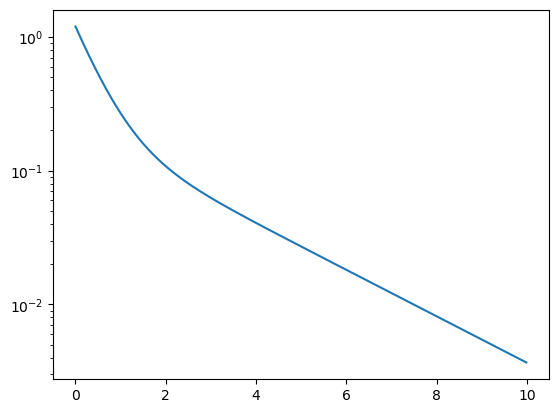

In [27]:
def exp_pdf(x:np.ndarray, tau:float)->np.ndarray:
    return np.exp(-x/tau)/tau


nexp_pdf = smfit.multi_dist(exp_pdf, ['tau', ], name='exponential')

x = np.r_[0:10:0.01]

pexp = np.array([
    0.5, # tau0
    0.5, # amp0
    2.5  # tau1
])

plt.semilogy(x, nexp_pdf(pexp, x))

#### Multi-dimensional N-dist functions

The `nd<dist>_...` functions are all creted with one of the following functions:
1. `multi_dist_nd()`
2. `multi_cdfbins_nd()`

- The `nd<dist>_pdf`, `nd<dist>_cdf`, and `nd<dist>_free` functions are created with `multi_dist_nd()`.
- The `nd<dist>_cdfbins` functions are created with `multi_cdfbins_nd()`.


The multi-dimensional functions are little more complicated.
This is because the size of the parameter depends on the number of dimensions.
So, instead of specifying a simple number, or sequence of names for the parameters,
special `mnd_...` functions are used.
Naming of parameters is therefore pushed to the param_names argument.

Input to the single dist function is handeled like 
`dist(x, *(mnd_func(params[start:stop], nd) for mnd_func, start, stop) in zip(mnd_funcs, starts, stops))`

`starts` and `stops` is computed by additional paramters supplied by the `mnd_funcs` (specified in the creation of the Nd N-disribution)
which specify the number of parameters needed based on the dimension (`nd`) of `x` ie `nd = x.shape[-1]`

Bellow is the code for the `nd<dist>_...` functions

In [28]:
# Nd distributions
ndgaus_pdf = smfit.multi_dist_nd(stats.multivariate_normal.pdf, (smfit.mnd_vec, smfit.mnd_covar), 
                           name='multivariate_normal.pdf', param_names=['mu', 'sigma'])
ndgaus_zerocovar_pdf = smfit.multi_dist_nd(stats.multivariate_normal.pdf, (smfit.mnd_vec, smfit.mnd_covar_zero), 
                                     name='multivariate_normal.pdf', param_names=['mu', 'sigma'])

ndgaus_cdf = smfit.multi_dist_nd(stats.multivariate_normal.cdf, (smfit.mnd_vec, smfit.mnd_covar), 
                           name='multivariate_normal.cdf', param_names=['mu', 'sigma'])
ndgaus_zerocovar_cdf = smfit.multi_dist_nd(stats.multivariate_normal.cdf, (smfit.mnd_vec, smfit.mnd_covar_zero), 
                                     name='multivariate_normal.cdf', param_names=['mu', 'sigma'])


ndgaus_cdfbins = smfit.multi_cdfbins_nd(stats.multivariate_normal.cdf, (smfit.mnd_vec, smfit.mnd_covar), 
                                  name='multivariate_normal.cdf', param_names=['mu', 'sigma'])
ndgaus_zerocovar_cdfbins = smfit.multi_cdfbins_nd(stats.multivariate_normal.cdf, (smfit.mnd_vec, smfit.mnd_covar_zero), 
                                            name='multivariate_normal.cdf', param_names=['mu', 'sigma'])

ndgaus_free = smfit.multi_dist_nd(stats.multivariate_normal.pdf, (smfit.mnd_vec, smfit.mnd_covar), free=True,
                            name='multivariate_normal.pdf', param_names=['mu', 'sigma'])
ndgaus_zerocovar_free = smfit.multi_dist_nd(stats.multivariate_normal.pdf, (smfit.mnd_vec, smfit.mnd_covar_zero), free=True,
                                      name='multivariate_normal.pdf', param_names=['mu', 'sigma'])

The `mnd_...` take a 1D array and reshape it to the approriate array, with whatever reflections etc.
are needed to support the distribution function.

The are all created with the `mnd_func()` decorator, which required 3 more functions as input.
These define functions that
1. `n = nfunc(nd:int)` take the dimensionallity of a distribution and return the number of parameters required
2. `nd = infunc(n:int)->nd`take the size of the parameters array and return the expected dimensionality
3. `params = inv(arr:np.ndarray)` the inverse of the converter function, `func(array:np.ndarray)->np.ndarray` where the return value is a 1D array

bellow is the code for `mnd_covar()` 
**note** that when creating your own `mnd_...` you must ensure all functions are mathematically correct, 
otherwise contradictions will arise and packing/unpacking will work incorrectly.

In [29]:
# code for smfit.mnd_covar
@smfit.mnd_func(lambda n: n*(n+1) // 2, lambda n: isqrt(8*n+1) // 2, lambda arr: arr[np.tri(arr.shape[0],dtype=np.bool_)].reshape(-1))
def mnd_covar(param:np.ndarray, nd:int)->np.ndarray:
    """Mnd function for covariance (symetric positive definite matrix), provide upper diagonal"""
    cov = np.empty((nd, nd))
    p = 0
    for i in range(nd):
        cov[i,i:] = param[p:p+nd-i]
        p += nd - i
    m = np.tri(nd, dtype=np.bool_)
    cov[m] = cov.T[m]
    return cov

## Multinomial fit

The `ndmultinomial_ratio_pmf()` is a N-multinomial distribution, where the ratio between event types is considered constant, but any total value is permitted.

The single distribution is as follows:

$f(x) = \frac{n!}{\prod_{i=1}^{N}{x_{i}!}}\prod_{i=1}^{N}{p_{i}^{x_{i}}}$

Where $x_{i}$ is the counts of event type $i$ occureing, and $p_{i}$ is the probability of producing event type $i$.
$n = \sum_{i=1}^{N}{x_{i}}$

The params are size $N-1$ as $\sum_{i}^{N}{p_{i}} = 1$ and therefore the same rescaling allows $p^{\prime}$ to be defined by the same rescaling as used for amplitudes.

This allows a simplified version of photon distribution analysis to be computed, that ignores background.

In [30]:
mninit = smfit.make_nd_init(smfit.ndmultinomial_ratio_pmf, [[0.5, 0.1,0.4], [0.3, 0.1, 0.6]])
mnbounds = np.zeros((mninit.size, 2))
mnbounds[:,1] = 1.0

In [31]:
res = smfit.fit_column_mle(data, (bs['NphDD_raw'], bs['NphDA_raw'], bs['NphAA_raw']), smfit.ndmultinomial_ratio_pmf, mninit, gate=gFret, bounds=mnbounds, method='Nelder-Mead')
res

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 35784.30965433725
             x: [ 3.149e-01  2.520e-01  7.294e-01  1.148e-01  3.515e-01]
           nit: 196
          nfev: 320
 final_simplex: (array([[ 3.149e-01,  2.520e-01, ...,  1.148e-01,
                         3.515e-01],
                       [ 3.149e-01,  2.520e-01, ...,  1.148e-01,
                         3.515e-01],
                       ...,
                       [ 3.149e-01,  2.520e-01, ...,  1.148e-01,
                         3.515e-01],
                       [ 3.149e-01,  2.520e-01, ...,  1.148e-01,
                         3.515e-01]], shape=(6, 5)), array([ 3.578e+04,  3.578e+04,  3.578e+04,  3.578e+04,
                        3.578e+04,  3.578e+04]))

In [32]:
ovals = smfit.unwrap_nd_param(smfit.ndmultinomial_ratio_pmf, 3, res.x)

for p, a in zip(ovals['p'], ovals['amps']):
    print(f'E: {p[1]/p[:2].sum()}, S: {p[:2].sum() / p.sum()}, amplitude: {a}')

E: 0.3541686209713945, S: 0.487535866488128, amplitude: 0.7294103196728468
E: 0.7305262621613352, S: 0.42595242851162085, amplitude: 0.27058968032715325


Note how E and S values must be computed as ratios of the output of multinomial, since the multinomial is fitting numbers of photons.